# Early Stopping + Loss History on SJAFFE

Trains five neural-net LDL models on the **SJAFFE** dataset with a uniform
recipe:

- max **2500** epochs (an upper bound — early stopping cuts it short),
- `LDLEarlyStopping(monitor='kl_divergence', patience=50)`, restoring
  best weights when triggered,
- `LossHistory` captures per-epoch training loss and validation KL,
- 80 / 20 train/test split (the test split doubles as the validation set
  for early-stopping signal).

For each model we plot training loss + validation KL on twin axes, then a
combined comparison and a final test-score table.


In [1]:
import importlib
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# force redownload of local moduls

import pyldl.utils
import pyldl.algorithms
importlib.reload(pyldl.utils)
importlib.reload(pyldl.algorithms)


from pyldl.utils import load_dataset, LDLEarlyStopping, LossHistory
from pyldl.algorithms import AA_BP, Duo_LDL, EDL, EDL_BAYES, BEDL, BEDL_BAYES, SNEFY_LDL, SA_BFGS, BOOJUM, BOOJUM_BAYES


## Load SJAFFE

In [2]:
X, D = load_dataset('Movie', dir='dataset')
X_train, X_test, D_train, D_test = train_test_split(X, D, test_size=0.2, random_state=0)
X_val, X_test, D_val, D_test = train_test_split(X_test, D_test, test_size=0.5, random_state=0)
print(f'X_train={X_train.shape}  D_train={D_train.shape}')
print(f'X_val  ={X_val.shape}    D_val  ={D_val.shape}')
print(f'X_test ={X_test.shape}   D_test ={D_test.shape}')

#only keep 500 training samples for faster training
# shuffle training set before subsampling
idx = np.random.permutation(X_train.shape[0])
X_train = X_train[idx][:500]
D_train = D_train[idx][:500]


X_train=(6204, 1869)  D_train=(6204, 5)
X_val  =(775, 1869)    D_val  =(775, 5)
X_test =(776, 1869)   D_test =(776, 5)


In [3]:
X_train.min(), X_train.max()

(0.0, 1.0)

## Training helper

`train_with_history` runs one model with the standard early-stopping +
loss-history callback pair and returns both the trained model and the
captured history.

`AA_BP` gets `AdamW(1e-2)` because its inherited default is
`SGD(1e-3)`, which converges far too slowly to see meaningful behaviour
inside 2500 epochs. The other four models inherit `Adam(1e-3)` from
`BaseAdam` and we leave that alone for an apples-to-apples comparison.


In [3]:
def train_with_history(name, model, kwargs, **fit_kwargs):
    history = LossHistory()
    callbacks = [
        LDLEarlyStopping(monitor='kl_divergence', patience=kwargs.get('patience', 50), minimum=kwargs.get('minimum', 100)),
        history,
    ]
    print(f'--- training {name} ---')
    model.fit(
        X_train, D_train,
        epochs=kwargs.get('max_epochs', 2500), batch_size=kwargs.get('batch_size', 64),
        X_val=X_val, D_val=D_val,
        callbacks=callbacks,
        optimizer=keras.optimizers.AdamW(learning_rate=kwargs.get('learning_rate', 1e-3), weight_decay=kwargs.get('weight_decay', 1e-4)),
        dropout_rate=kwargs.get('dropout_rate', 0.2),
        **fit_kwargs
    )
    n_epochs = len(history.history.get('loss', []))
    print(f'  finished after {n_epochs} epochs')
    return model, history


## Train each model

In [ ]:
results = {}

In [25]:
kwargs = {
        'learning_rate': 1e-3,
        'weight_decay': 1e-2,
        'dropout_rate': 0.2,
        'n_hidden': 4,
        'patience': 10,
        'minimum': 4,
        'max_epochs': 1000,
        'batch_size': 32,
}


# results['AA_BP'] = train_with_history(
#     'AA_BP', AA_BP(n_hidden=kwargs['n_hidden']), kwargs=kwargs)
# results['Duo_LDL']   = train_with_history(
#     'Duo_LDL',   Duo_LDL(n_hidden=kwargs['n_hidden']), kwargs=kwargs)
results['EDL']   = train_with_history(
    'EDL',   EDL(n_hidden=kwargs['n_hidden']), kwargs=kwargs)
results['BEDL']  = train_with_history(
    'BEDL',  BEDL(n_hidden=kwargs['n_hidden']), kwargs=kwargs)
results['EDL_BAYES']   = train_with_history(
    'EDL_BAYES',   EDL_BAYES(n_hidden=kwargs['n_hidden']), kwargs=kwargs)
results['BEDL_BAYES']  = train_with_history(
    'BEDL_BAYES',  BEDL_BAYES(n_hidden=kwargs['n_hidden']), kwargs=kwargs)
results['BOOJUM'] = train_with_history(
    'BOOJUM', BOOJUM(n_hidden=kwargs['n_hidden']), kwargs=kwargs)
results['BOOJUM_BAYES'] = train_with_history(
    'BOOJUM_BAYES', BOOJUM_BAYES(n_hidden=kwargs['n_hidden']), kwargs=kwargs)

--- training EDL ---
  finished after 150 epochs
--- training BEDL ---
  finished after 73 epochs
--- training EDL_BAYES ---
  finished after 51 epochs
--- training BEDL_BAYES ---
  finished after 35 epochs
--- training BOOJUM ---
  finished after 69 epochs
--- training BOOJUM_BAYES ---
  finished after 63 epochs


## Per-model loss curves

Training loss (blue, left axis) and validation KL divergence (red, right
axis) on twin axes. Early-stopping fires when the val-KL curve fails to
improve for 50 epochs; the model's final weights are restored to the
best-val-KL epoch.


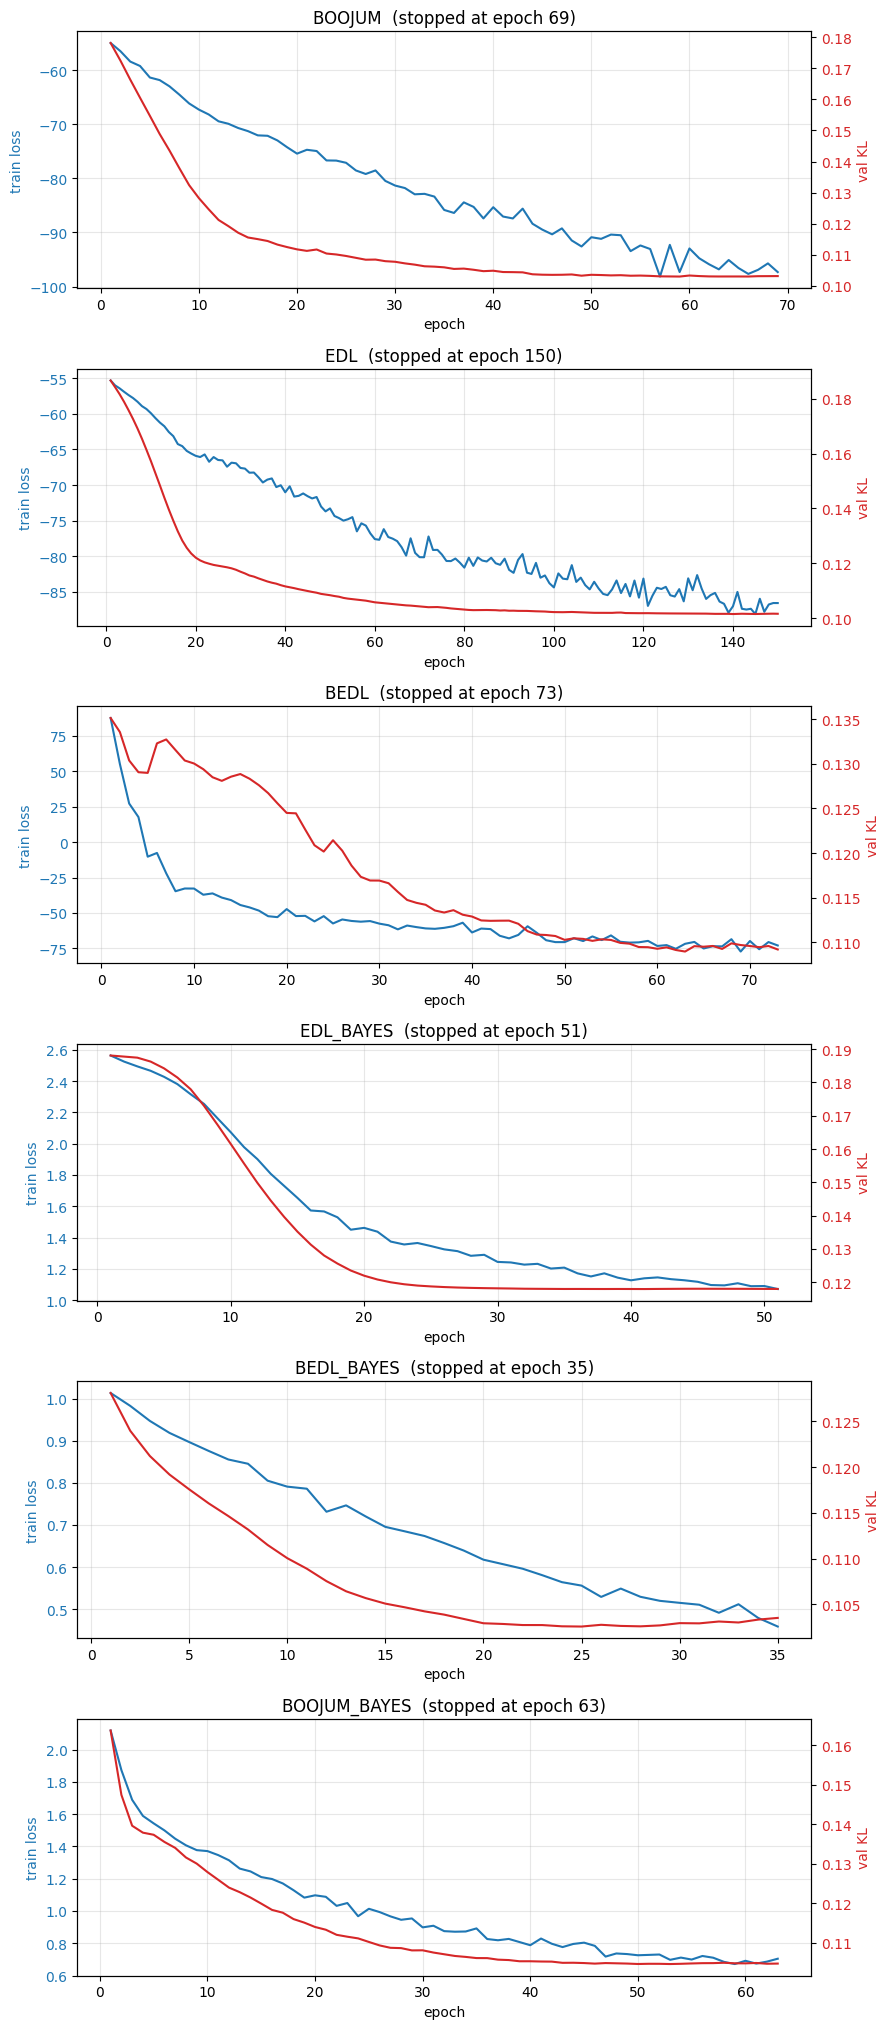

In [26]:
fig, axes = plt.subplots(len(results), 1, figsize=(9, 3.4 * len(results)), squeeze=False)

for ax_row, (name, (_, h)) in zip(axes, results.items()):
    ax = ax_row[0]
    ep = range(1, len(h.history['loss']) + 1)
    ax.plot(ep, h.history['loss'], color='C0', label='train loss')
    ax.set_xlabel('epoch')
    ax.set_ylabel('train loss', color='C0')
    ax.tick_params(axis='y', labelcolor='C0')

    ax2 = ax.twinx()
    ax2.plot(ep, h.history['kl_divergence'], color='C3', label='val KL')
    ax2.set_ylabel('val KL', color='C3')
    ax2.tick_params(axis='y', labelcolor='C3')

    ax.set_title(f'{name}  (stopped at epoch {len(ep)})')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Validation KL comparison across models

All five val-KL curves on a single axis. Useful for seeing which models
converge faster vs. which reach a lower final KL.


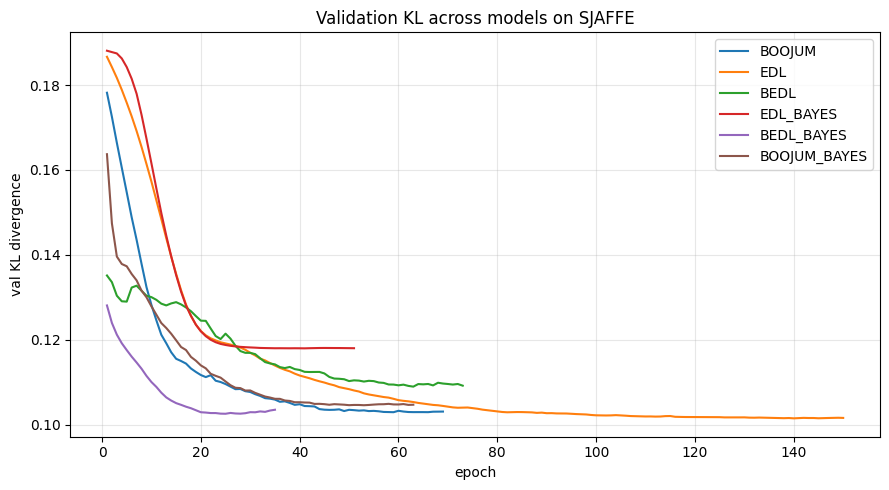

In [27]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, (_, h) in results.items():
    kl = h.history['kl_divergence']
    ax.plot(range(1, len(kl) + 1), kl, label=name)

ax.set_xlabel('epoch'); ax.set_ylabel('val KL divergence')
ax.set_title('Validation KL across models on SJAFFE')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Final test-set scores

Computed on `X_test` / `D_test` after early-stopping has restored each
model to its best-val-KL weights.


In [28]:
METRICS = ['chebyshev', 'clark', 'canberra', 'kl_divergence', 'cosine', 'intersection']

rows = []
for name, (model, h) in results.items():
    s = model.score(X_test, D_test, metrics=METRICS, return_dict=True)
    rows.append({
        'model': name,
        'epochs_run': len(h.history.get('loss', [])),
        **{k: float(v) for k, v in s.items()},
    })

scores_df = pd.DataFrame(rows).set_index('model')
scores_df


,epochs_run,chebyshev,clark,canberra,kl_divergence,cosine,intersection
model,,,,,,,
BOOJUM,69,0.120530,0.542380,1.039726,0.107216,0.928546,0.826626
EDL,150,0.120126,0.537594,1.034371,0.107554,0.928148,0.827311
BEDL,73,0.124516,0.548366,1.054988,0.114452,0.923007,0.822243
EDL_BAYES,51,0.130596,0.587086,1.119567,0.123445,0.918632,0.811779
BEDL_BAYES,35,0.119995,0.534653,1.025385,0.107025,0.928601,0.828683
BOOJUM_BAYES,63,0.123217,0.553309,1.054036,0.109933,0.927016,0.824096


In [21]:
sa_bfgs_mod = SA_BFGS()
sa_bfgs_mod.fit(X_train, D_train)
scores = sa_bfgs_mod.score(X_test, D_test, return_dict=True)
print(f'--- {sa_bfgs_mod.__class__.__name__} ---')
for k, v in scores.items():
    print(f'{k}: {v:.4f}')

--- SA_BFGS ---
chebyshev: 0.1937
clark: 0.7312
canberra: 1.4199
kl_divergence: 0.2458
cosine: 0.8571
intersection: 0.7489
